In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score, mean_squared_error

# NB: df is a dataframe used to store my csv dataset for easy recall or access to the dataset.

In [2]:
# Read the Housing Pinky.csv dataset

df = pd.read_csv('C:\\Users\\BOLYTECH.COMPUTERS\\Desktop\\Pinkardudu\\Dataset\\Housing Pinky.csv')

# from properties you get the location of your CSV dataset.
# Dataset alredy imported in my Notebook.

In [3]:
df.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [4]:
df.tail(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,INLAND
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,INLAND
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,INLAND
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,INLAND
20639,-121.24,39.37,16,2785,616.0,1387,530,2.3886,89400,INLAND


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
longitude             20640 non-null float64
latitude              20640 non-null float64
housing_median_age    20640 non-null int64
total_rooms           20640 non-null int64
total_bedrooms        20433 non-null float64
population            20640 non-null int64
households            20640 non-null int64
median_income         20640 non-null float64
median_house_value    20640 non-null int64
ocean_proximity       20640 non-null object
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [6]:
df.shape

(20640, 10)

In [7]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [8]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age      int64
total_rooms             int64
total_bedrooms        float64
population              int64
households              int64
median_income         float64
median_house_value      int64
ocean_proximity        object
dtype: object

In [9]:
df.index

RangeIndex(start=0, stop=20640, step=1)

In [10]:
# checking for missing values

df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [11]:
# replacing missing values with median

df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

In [12]:
# after handling the missing values cross check all to be 0
print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [13]:
# Checking for duplicate rows

df.duplicated().sum()

0

In [14]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,536.838857,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.391878,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [15]:
df["ocean_proximity"].value_counts()

<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: ocean_proximity, dtype: int64

In [16]:
df[["median_income","median_house_value"]].head()

,median_income,median_house_value
0,8.3252,452600
1,8.3014,358500
2,7.2574,352100
3,5.6431,341300
4,3.8462,342200


In [17]:
df[["median_income","median_house_value"]].describe()

,median_income,median_house_value
count,20640.000000,20640.000000
mean,3.870671,206855.816909
std,1.899822,115395.615874
min,0.499900,14999.000000
25%,2.563400,119600.000000
50%,3.534800,179700.000000
75%,4.743250,264725.000000
max,15.000100,500001.000000


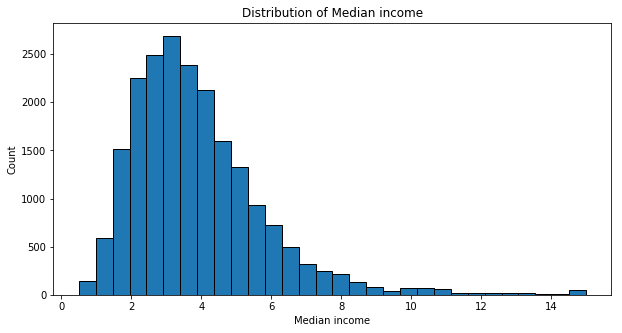

In [18]:
# Histogram for median_income

plt.figure(figsize=(10,5))
plt.hist(df['median_income'], bins=30,edgecolor='black')
plt.title('Distribution of Median income')
plt.xlabel('Median income')
plt.ylabel('Count')
plt.show()

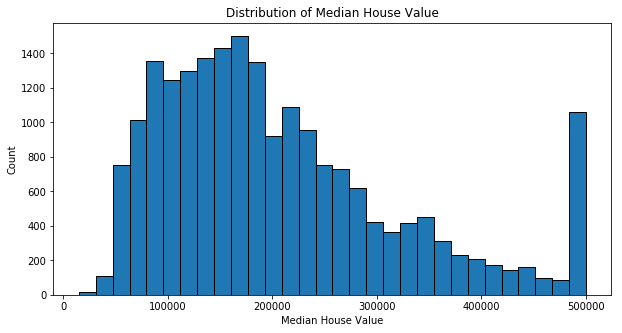

In [19]:
# Histogram for median_house_value
plt.figure(figsize=(10,5))
plt.hist(df['median_house_value'], bins=30,edgecolor='black')
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Count')
plt.show()

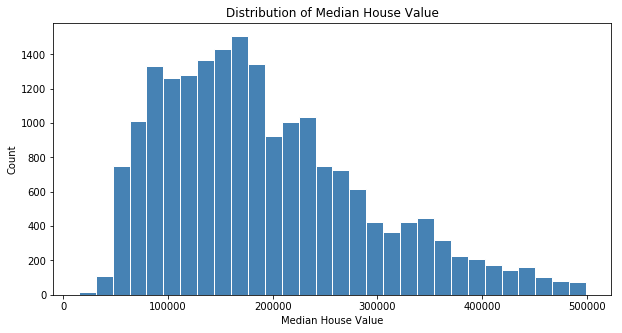

In [20]:
# this output show the trimmed capped values for the median house value entirely from the hist plot.

df_filtered = df[df['median_house_value'] < 500000]

plt.figure(figsize=(10, 5))
plt.hist(df_filtered['median_house_value'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Count')
plt.show()

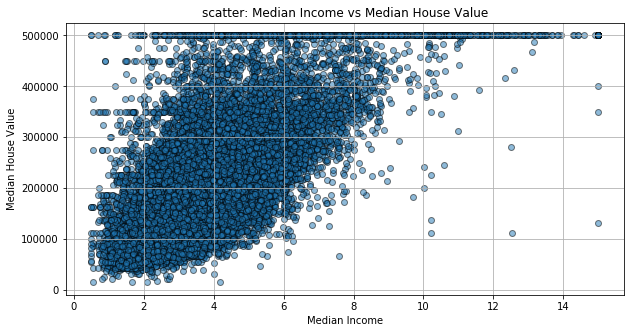

In [21]:
# Create a scatter plot
plt.figure(figsize=(10,5))
plt.scatter(df['median_income'], df['median_house_value'], alpha=0.5, edgecolor='k')
plt.title('scatter: Median Income vs Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.grid(True)
plt.show()

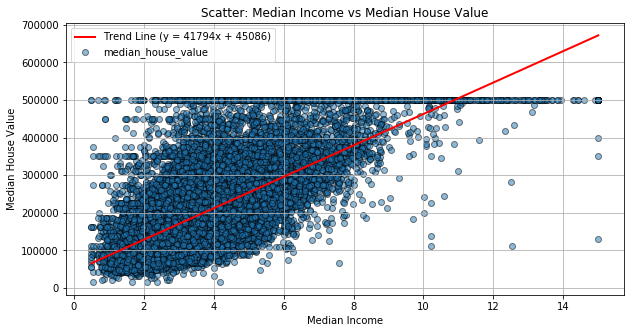

In [22]:
# Create scatter plot with trend line

plt.figure(figsize=(10, 5))
plt.scatter(df['median_income'], df['median_house_value'], alpha=0.5, edgecolor='k')

# --- Add Trend Line ---

m, b = np.polyfit(df['median_income'], df['median_house_value'], 1)
x_line = np.linspace(df['median_income'].min(), df['median_income'].max(), 100)
y_line = m * x_line + b
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Trend Line (y = {m:.0f}x + {b:.0f})')

plt.title('Scatter: Median Income vs Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.legend()
plt.grid(True)
plt.show()

Positive Trend
There is a clear upward pattern as median income increases median house value aslo incereases.
This confirm a positive correlaton making it suitable for simple linear regression.

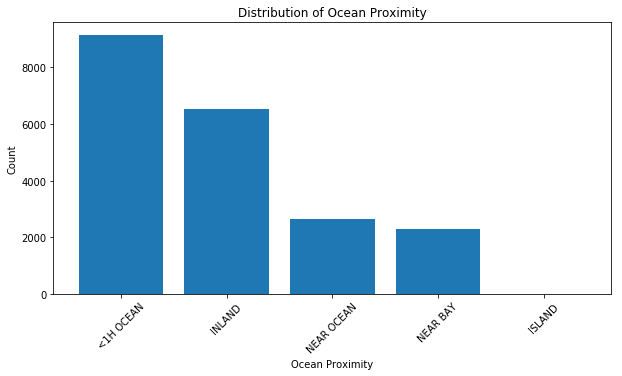

In [23]:
# Ocean proximity analysis

plt.figure(figsize=(10, 5))
ocean_counts = df['ocean_proximity'].value_counts()
plt.bar(ocean_counts.index, ocean_counts.values)
plt.title('Distribution of Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [24]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [25]:
# Identify numeric columns

numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
print("Numeric Columns:", numeric_columns)

Numeric Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


In [26]:
# Identify categorical columns

categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical Columns:", categorical_columns)

Categorical Columns: ['ocean_proximity']


In [27]:
df.describe(include='object')

,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


In [28]:
numeric_df = df._get_numeric_data()
print(numeric_df)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                  41          880           129.0   
1        -122.22     37.86                  21         7099          1106.0   
2        -122.24     37.85                  52         1467           190.0   
3        -122.25     37.85                  52         1274           235.0   
4        -122.25     37.85                  52         1627           280.0   
5        -122.25     37.85                  52          919           213.0   
6        -122.25     37.84                  52         2535           489.0   
7        -122.25     37.84                  52         3104           687.0   
8        -122.26     37.84                  42         2555           665.0   
9        -122.25     37.84                  52         3549           707.0   
10       -122.26     37.85                  52         2202           434.0   
11       -122.26     37.85                  52      

# Train Linear Regression Model

In [29]:
# define features as (X) and Target (Y)
X = df[['median_income']] # Feature Note: the double bracket to keep X as a dataframe
Y = df['median_house_value'] # Target

print(X.shape)
print(Y.shape)

(20640, 1)
(20640,)


In [30]:
# Check current columns
print(df.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


In [31]:
# Before Encoding

df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)
print("Columns before encoding:", df.columns.tolist())

Columns before encoding: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


In [32]:
# After Encoding

df_encoded = pd.get_dummies(df, columns=['ocean_proximity'])
print("Columns after encoding:", df_encoded.columns.tolist())

Columns after encoding: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [33]:
# Define X and Y

X = df_encoded.drop('median_house_value', axis=1)
Y = df_encoded['median_house_value']

print("\nShape of X:", X.shape)


Shape of X: (20640, 13)


In [34]:
# Split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (16512, 13)
X_test shape: (4128, 13)


In [35]:
# Retrain model using current X_train

model = LinearRegression()
model.fit(X_train, Y_train)

# Now coefficients will match
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})
print(coefficients)
print("Intercept:", round(model.intercept_, 2))

                       Feature    Coefficient
0                    longitude  -26838.273372
1                     latitude  -25468.352050
2           housing_median_age    1102.185084
3                  total_rooms      -6.021506
4               total_bedrooms     102.789395
5                   population     -38.172906
6                   households      48.252753
7                median_income   39473.975175
8    ocean_proximity_<1H OCEAN  -18926.582862
9       ocean_proximity_INLAND  -58713.239023
10      ocean_proximity_ISLAND  117198.489753
11    ocean_proximity_NEAR BAY  -24063.225079
12  ocean_proximity_NEAR OCEAN  -15495.442789
Intercept: -2256620.8


In [36]:
Y_pred = model.predict(X_train)

# Compare actual vs predicted
results = pd.DataFrame({
    'Actual': Y_train.values,
    'Predicted': Y_pred.round(2),
    'Difference': (Y_train.values - Y_pred).round(2)
})

display(results.head())

,Actual,Predicted,Difference
0,103000,188628.08,-85628.08
1,382100,290379.89,91720.11
2,172600,250985.48,-78385.48
3,93400,146878.08,-53478.08
4,96500,165789.41,-69289.41


In [37]:
Y_pred = model.predict(X_test)

# Compare actual vs predicted
results = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': Y_pred.round(2),
    'Difference': (Y_test.values - Y_pred).round(2)
})

display(results.head())

,Actual,Predicted,Difference
0,47700,54055.45,-6355.45
1,45800,124225.34,-78425.34
2,500001,255489.38,244511.62
3,218600,268002.43,-49402.43
4,278000,262769.43,15230.57


In [38]:
# Train Linear Regression

model = LinearRegression()
model.fit(X_train, Y_train)
Y_pred_train_lr = model.predict(X_train)
Y_pred_test_lr = model.predict(X_test)

print("\nLinear Regression Results:")
print("Train R²:", round(r2_score(Y_train, Y_pred_train_lr), 2))
print("Test R²:", round(r2_score(Y_test, Y_pred_test_lr), 2))


Linear Regression Results:
Train R²: 0.65
Test R²: 0.63


In [39]:
# Train Random Forest

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)

# Now predict
Y_pred_train_rf = rf_model.predict(X_train)
Y_pred_test_rf = rf_model.predict(X_test)

print("\nRandom Forest Results:")
print("Train R²:", round(r2_score(Y_train, Y_pred_train_rf), 2))
print("Test R²:", round(r2_score(Y_test, Y_pred_test_rf), 2))


Random Forest Results:
Train R²: 0.98
Test R²: 0.82


In [40]:
# Get predictions
Y_pred_train = model.predict(X_train)
Y_pred_test = model.predict(X_test)

In [41]:
# Calculate metrics

MAE = mean_absolute_error(Y_test, Y_pred_test)

# Round the results

MAE = round(MAE, 2)

# Print results
print(MAE)

50670.74


In [42]:
average_house_price = df['median_house_value'].mean()
MAE_percentage_of_avg = (MAE / average_house_price) * 100

print(round(MAE_percentage_of_avg, 2))

24.5


In [43]:
# Linear Regression train test output

print("RMSE:", round(np.sqrt(mean_squared_error(Y_test, Y_pred_test_lr)), 2))
print("MAE:", round(mean_absolute_error(Y_test, Y_pred_test_lr), 2))

RMSE: 70060.52
MAE: 50670.74


In [44]:
# Random forest train test output

print("RMSE:", round(np.sqrt(mean_squared_error(Y_test, Y_pred_test_rf)), 2))
print("MAE:", round(mean_absolute_error(Y_test, Y_pred_test_rf), 2))

RMSE: 48977.75
MAE: 31636.19


A few things to keep in mind:

Random Forest (your current results: 
Train R² 0.98, Test R² 0.82) is a powerful ensemble model that handles non-linear relationships well.

Linear Regression assumes a straight-line relationship between features and target.
R² scores may likely be lower if the data has non-linear patterns.

The high gap between Train R² (0.98) and Test R² (0.82) in your Random Forest suggests some overfitting — 
Linear Regression might actually generalise better in some cases, but with lower overall accuracy.

Note:

Random Forest is clearly the better model for this dataset. 
It explains 82% of the variance vs Linear Regression's 63%.

Linear Regression's RMSE and MAE are significantly higher, meaning its predictions are further off on average.
The fact that Linear Regression's Train and Test R² are close (0.65 vs 0.63) shows it's consistent but weak — 
it's underfitting the data.

Random Forest handles the non-linear relationships in this data much better.

In [45]:
# Dot notation to access model attributes or to get model parameter

slope = round(model.coef_[0], 2)
intercept = round(model.intercept_, 2)

print("Slope:", slope)
print("Intercept:", intercept)

Slope: -26838.27
Intercept: -2256620.8


In [46]:
# checking the lengths of the columns

print("X_train columns:", len(X_train.columns))
print("Model coefficients:", len(model.coef_))

X_train columns: 13
Model coefficients: 13


In [47]:
print("NaN values:\n", X_train.isnull().sum())
print("\nNaN in Y_train:", Y_train.isnull().sum())

NaN values:
 longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
ocean_proximity_<1H OCEAN     0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64

NaN in Y_train: 0


In [48]:
print("Infinity in X_train:", np.isinf(X_train).sum().sum())
print("Infinity in Y_train:", np.isinf(Y_train).sum())

Infinity in X_train: 0
Infinity in Y_train: 0


In [49]:
# Replace infinity with NaN first, then fill NaN with median

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

print("All clean")
print("NaN remaining:", X_train.isnull().sum().sum())

All clean
NaN remaining: 0


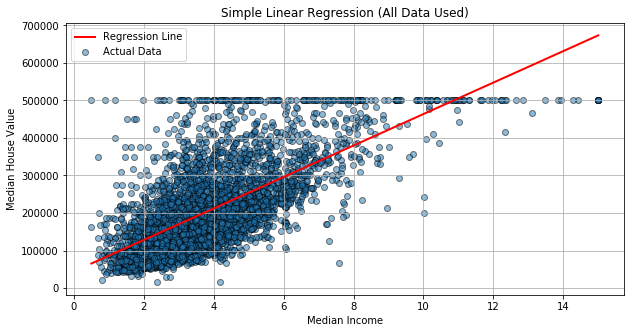

In [50]:
# Use only median_income as single feature
X_plot = X_test[['median_income']].values

# Train a simple Linear Regression on single feature
lr = LinearRegression()
lr.fit(X_train[['median_income']], Y_train)

# Generate straight line predictions
X_line = np.linspace(X_plot.min(), X_plot.max(), 300).reshape(-1, 1)
Y_line = lr.predict(X_line)

# Plot
plt.figure(figsize=(10, 5))
plt.scatter(X_plot, Y_test, alpha=0.5, edgecolor='k', label='Actual Data')
plt.plot(X_line, Y_line, color='red', linewidth=2, label='Regression Line')
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Simple Linear Regression (All Data Used)")
plt.legend()
plt.grid(True)
plt.show()

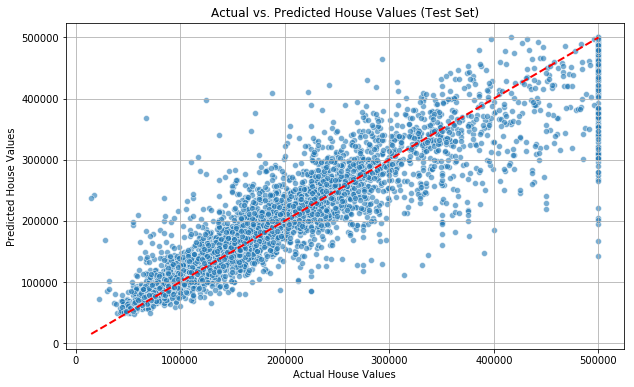

In [51]:
# Get predictions
Y_pred_test = rf_model.predict(X_test)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=Y_test, y=Y_pred_test, alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.xlabel('Actual House Values')
plt.ylabel('Predicted House Values')
plt.title('Actual vs. Predicted House Values (Test Set)')
plt.grid(True)
plt.show()

In [52]:
# Features (multiple predictors)
X = df[['longitude', 'latitude', 'housing_median_age', 'total_rooms',
        'total_bedrooms', 'population', 'households', 'median_income']]

# Target variable
Y = df['median_house_value']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Output to check shapes and preview
print("=== SHAPES ===")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test:", Y_test.shape)

print("\n=== FEATURE PREVIEW (X_train) ===")
print(X_train.head())

print("\n=== TARGET PREVIEW (Y_train) ===")
print(Y_train.head())

=== SHAPES ===
X_train: (16512, 8)
X_test: (4128, 8)
Y_train: (16512,)
Y_test: (4128,)

=== FEATURE PREVIEW (X_train) ===
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
14196    -117.03     32.71                  33         3126           627.0   
8267     -118.16     33.77                  49         3382           787.0   
17445    -120.48     34.66                   4         1897           331.0   
14265    -117.11     32.69                  36         1421           367.0   
2271     -119.80     36.78                  43         2382           431.0   

       population  households  median_income  
14196        2300         623         3.2596  
8267         1314         756         3.8125  
17445         915         336         4.1563  
14265        1418         355         1.9425  
2271          874         380         3.5542  

=== TARGET PREVIEW (Y_train) ===
14196    103000
8267     382100
17445    172600
14265     93400
2271      96500
Name: m

In [53]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [54]:
print("\n" + "=" * 55)
print("  DATA MODEL COMPLETE")
print("=" * 55)


  DATA MODEL COMPLETE
